In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import seaborn as sns
from wordcloud import WordCloud

In [ ]:
# load a file
df =pd.read_csv("udemy_courses (2).csv", skiprows=3050 ,names =
  ['course_id','course_title','url','is_paid','price','num_subscribers','num_reviews',
   'num_lectures','v','content_duration' ,'published_timestamp','subject'])


In [ ]:
df #Udemy online course platform dataset showing the number of subscribers, reviews,lectures for each subject and the published time


,course_id,course_title,url,is_paid,price,num_subscribers,num_reviews,num_lectures,v,content_duration,published_timestamp,subject
0,130168,HTML and CSS for Beginning Web Developers,https://www.udemy.com/html-and-css-for-beginni...,True,100,1606,28,73,Beginner Level,9.000000,2013-12-13T18:19:58Z,Web Development
1,1002210,Popular JavaScript Framework:Learn The Languag...,https://www.udemy.com/popular-javascript-frame...,True,200,260,22,64,Beginner Level,11.000000,2016-11-11T21:27:55Z,Web Development
2,1076424,The Ultimate Guide to the Best WordPress Plugi...,https://www.udemy.com/wordpress-plugins-a-guid...,True,50,122,10,116,All Levels,10.500000,2017-02-16T23:30:02Z,Web Development
3,968278,XSLT :basics for beginners,https://www.udemy.com/xslt-basics-for-beginners/,True,35,877,6,7,All Levels,0.533333,2016-09-27T15:14:59Z,Web Development
4,50528,The Complete Wordpress Plugin Development Cour...,https://www.udemy.com/wordpress-plugin-develop...,True,200,1215,58,33,All Levels,2.500000,2013-05-29T15:09:48Z,Web Development
...,...,...,...,...,...,...,...,...,...,...,...,...
624,775618,Learn jQuery from Scratch - Master of JavaScri...,https://www.udemy.com/easy-jquery-for-beginner...,True,100,1040,14,21,All Levels,2.000000,2016-06-14T17:36:46Z,Web Development
625,1088178,How To Design A WordPress Website With No Codi...,https://www.udemy.com/how-to-make-a-wordpress-...,True,25,306,3,42,Beginner Level,3.500000,2017-03-10T22:24:30Z,Web Development
626,635248,Learn and Build using Polymer,https://www.udemy.com/learn-and-build-using-po...,True,40,513,169,48,All Levels,3.500000,2015-12-30T16:41:42Z,Web Development
627,905096,CSS Animations: Create Amazing Effects on Your...,https://www.udemy.com/css-animations-create-am...,True,50,300,31,38,All Levels,3.000000,2016-08-11T19:06:15Z,Web Development


# **Removing duplicates :**

In [ ]:
# a method prints a message if potential duplicates occurred otherwise another message will print
def return_duplicates():
    if df.duplicated().any():
        print('duplicates were found')
    else:
         print('no duplicates were found')

In [ ]:
# calling return_duplicates() method
return_duplicates()

no duplicates were found


In [ ]:
df.isnull().sum()#check for missing values in a DataFrame.

,0
course_id,0
course_title,0
url,0
is_paid,0
price,0
num_subscribers,0
num_reviews,0
num_lectures,0
v,0
content_duration,0


In [ ]:
df.isnull().values.any()#check if there are any missing values in the entire DataFrame.

False

# **Reformatting data:**

In [ ]:
df.columns = df.columns.str.replace('_', ' ').str.title() #format the names of columns

In [ ]:
#formatting the date in column Published Timestamp
df['Published Timestamp']=df['Published Timestamp'].map(lambda x:re.sub(r'-', r'/', x))
df['Published Timestamp']=df['Published Timestamp'].map(lambda x:re.sub(r'[TZ]', ' ', x))

In [ ]:
df

,Course Id,Course Title,Url,Is Paid,Price,Num Subscribers,Num Reviews,Num Lectures,V,Content Duration,Published Timestamp,Subject
0,130168,HTML and CSS for Beginning Web Developers,https://www.udemy.com/html-and-css-for-beginni...,True,100,1606,28,73,Beginner Level,9.000000,2013/12/13 18:19:58,Web Development
1,1002210,Popular JavaScript Framework:Learn The Languag...,https://www.udemy.com/popular-javascript-frame...,True,200,260,22,64,Beginner Level,11.000000,2016/11/11 21:27:55,Web Development
2,1076424,The Ultimate Guide to the Best WordPress Plugi...,https://www.udemy.com/wordpress-plugins-a-guid...,True,50,122,10,116,All Levels,10.500000,2017/02/16 23:30:02,Web Development
3,968278,XSLT :basics for beginners,https://www.udemy.com/xslt-basics-for-beginners/,True,35,877,6,7,All Levels,0.533333,2016/09/27 15:14:59,Web Development
4,50528,The Complete Wordpress Plugin Development Cour...,https://www.udemy.com/wordpress-plugin-develop...,True,200,1215,58,33,All Levels,2.500000,2013/05/29 15:09:48,Web Development
...,...,...,...,...,...,...,...,...,...,...,...,...
624,775618,Learn jQuery from Scratch - Master of JavaScri...,https://www.udemy.com/easy-jquery-for-beginner...,True,100,1040,14,21,All Levels,2.000000,2016/06/14 17:36:46,Web Development
625,1088178,How To Design A WordPress Website With No Codi...,https://www.udemy.com/how-to-make-a-wordpress-...,True,25,306,3,42,Beginner Level,3.500000,2017/03/10 22:24:30,Web Development
626,635248,Learn and Build using Polymer,https://www.udemy.com/learn-and-build-using-po...,True,40,513,169,48,All Levels,3.500000,2015/12/30 16:41:42,Web Development
627,905096,CSS Animations: Create Amazing Effects on Your...,https://www.udemy.com/css-animations-create-am...,True,50,300,31,38,All Levels,3.000000,2016/08/11 19:06:15,Web Development


# **Validating data:**

In [ ]:
df.dtypes #checking data types

,0
Course Id,int64
Course Title,object
Url,object
Is Paid,bool
Price,int64
Num Subscribers,int64
Num Reviews,int64
Num Lectures,int64
V,object
Content Duration,float64


In [ ]:
df['Course Id'].astype(str).str.match(r'\d{5,7}')#check if each course id is between five and seven digits

,Course Id
0,True
1,True
2,True
3,True
4,True
...,...
624,True
625,True
626,True
627,True


In [ ]:
def is_int(i):# method check if the numerical values is positive integer
    if i>=0:
      return True
    else:
     return False

In [ ]:
df[['Num Subscribers','Num Reviews','Num Lectures','Price']].map(is_int)#applay the method to each element in the specified columns

,Num Subscribers,Num Reviews,Num Lectures,Price
0,True,True,True,True
1,True,True,True,True
2,True,True,True,True
3,True,True,True,True
4,True,True,True,True
...,...,...,...,...
624,True,True,True,True
625,True,True,True,True
626,True,True,True,True
627,True,True,True,True


# **Normalizing or scaling data:**

In [ ]:

def normalize_data(df, columns): # A method for normalizing data
  df_nor= df.copy()
  for i in columns:
    min_val = df_nor[i].min()
    max_val = df_nor[i].max()
    df_nor[i] = round(1+9*(df_nor[i] - min_val) / (max_val - min_val)) #Make value between 1 and 10
  return df_nor

In [ ]:
normalize = ['Price', 'Num Subscribers', 'Num Reviews', 'Num Lectures', 'Content Duration']
df_normalized = normalize_data(df, normalize)

print(df_normalized)

     Course Id                                       Course Title  \
0       130168          HTML and CSS for Beginning Web Developers   
1      1002210  Popular JavaScript Framework:Learn The Languag...   
2      1076424  The Ultimate Guide to the Best WordPress Plugi...   
3       968278                         XSLT :basics for beginners   
4        50528  The Complete Wordpress Plugin Development Cour...   
..         ...                                                ...   
624     775618  Learn jQuery from Scratch - Master of JavaScri...   
625    1088178  How To Design A WordPress Website With No Codi...   
626     635248                      Learn and Build using Polymer   
627     905096  CSS Animations: Create Amazing Effects on Your...   
628     297602  Using MODX CMS to Build Websites: A Beginner's...   

                                                   Url  Is Paid  Price  \
0    https://www.udemy.com/html-and-css-for-beginni...     True    6.0   
1    https://www.udemy.

# **Tokenizing text data:**

In [ ]:
#splits the text in the 'Course Title' column
df['tokenized_course_title'] = df['Course Title'].str.split()


In [ ]:

print(df[['Course Title', 'tokenized_course_title']])


                                          Course Title  \
0            HTML and CSS for Beginning Web Developers   
1    Popular JavaScript Framework:Learn The Languag...   
2    The Ultimate Guide to the Best WordPress Plugi...   
3                           XSLT :basics for beginners   
4    The Complete Wordpress Plugin Development Cour...   
..                                                 ...   
624  Learn jQuery from Scratch - Master of JavaScri...   
625  How To Design A WordPress Website With No Codi...   
626                      Learn and Build using Polymer   
627  CSS Animations: Create Amazing Effects on Your...   
628  Using MODX CMS to Build Websites: A Beginner's...   

                                tokenized_course_title  
0    [HTML, and, CSS, for, Beginning, Web, Developers]  
1    [Popular, JavaScript, Framework:Learn, The, La...  
2    [The, Ultimate, Guide, to, the, Best, WordPres...  
3                      [XSLT, :basics, for, beginners]  
4    [The, Complet

## **Central values:**

In [ ]:
def central_values (df,col):  #method uses pandas libary to calculate central values



    mean_value = df[col].mean()
    print("mean Value : ", mean_value)
    median_value = df[col].median()
    print("median Value : ", median_value)
    mode_value = df[col].mode()
    print("mode Value : ", mode_value)



    return mean_value,median_value,mode_value

In [ ]:
central_values(df,'Price')

mean Value :  71.91573926868044
median Value :  50.0
mode Value :  0    0
Name: Price, dtype: int64


(71.91573926868044,
 50.0,
 0    0
 Name: Price, dtype: int64)

In [ ]:
central_values(df,'Num Subscribers')

mean Value :  5766.489666136725
median Value :  1769.0
mode Value :  0    578
1    586
Name: Num Subscribers, dtype: int64


(5766.489666136725,
 1769.0,
 0    578
 1    586
 Name: Num Subscribers, dtype: int64)

In [ ]:
central_values(df,'Num Reviews')

mean Value :  463.09697933227346
median Value :  54.0
mode Value :  0    8
Name: Num Reviews, dtype: int64


(463.09697933227346,
 54.0,
 0    8
 Name: Num Reviews, dtype: int64)

In [ ]:
central_values(df,'Num Lectures')

mean Value :  50.64069952305246
median Value :  31.0
mode Value :  0    18
Name: Num Lectures, dtype: int64


(50.64069952305246,
 31.0,
 0    18
 Name: Num Lectures, dtype: int64)

In [ ]:
central_values(df,'Content Duration')

mean Value :  5.238818229994701
median Value :  3.0
mode Value :  0    2.0
Name: Content Duration, dtype: float64


(5.238818229994701,
 3.0,
 0    2.0
 Name: Content Duration, dtype: float64)

# **Calculating the correlation**

In [ ]:
correlation=df[['Num Subscribers','Num Reviews','Num Lectures','Price','Content Duration']].corr()#calculate the correlation

In [ ]:
correlation

,Num Subscribers,Num Reviews,Num Lectures,Price,Content Duration
Num Subscribers,1.000000,0.819303,0.274679,0.137923,0.277232
Num Reviews,0.819303,1.000000,0.391264,0.221752,0.357517
Num Lectures,0.274679,0.391264,1.000000,0.430134,0.863611
Price,0.137923,0.221752,0.430134,1.000000,0.394781
Content Duration,0.277232,0.357517,0.863611,0.394781,1.000000


# ***word frequency analysis:***

In [ ]:
word_counts = {}
#Counts how many times each word appers in 'tokenized_course_title'
for words in df['tokenized_course_title']:
    for word in words:
        word = word.lower()
        if len(word) > 3:
            if word in word_counts: # If the word exists in the dictionary add 1
                word_counts[word] += 1
            else: # If the word is not in the dictionary add it with number 1
                word_counts[word] = 1

print(word_counts)




{'html': 55, 'beginning': 2, 'developers': 16, 'popular': 2, 'javascript': 64, 'framework:learn': 1, 'language': 1, 'angular': 28, 'ultimate': 9, 'guide': 27, 'best': 1, 'wordpress': 72, 'plugins': 6, 'part': 3, 'xslt': 2, ':basics': 10, 'beginners': 69, 'complete': 46, 'plugin': 5, 'development': 47, 'course': 37, 'json': 8, 'crash': 7, 'create': 55, 'incredible': 1, 'websites': 33, 'with': 120, 'learn': 119, 'tricks': 2, 'code': 7, 'projects': 18, 'from': 54, 'scratch': 36, 'sass': 6, 'course!': 1, 'real-world': 4, 'design': 17, 'website': 54, 'bootstrap': 31, 'master': 14, 'example': 6, 'build': 74, 'awesome': 3, 'apps!': 1, 'custom': 4, 'responsive': 22, 'client': 2, 'mastering': 9, 'html5': 32, 'programming': 17, 'easier': 1, 'launch': 3, 'your': 36, 'builder': 2, 'service': 2, 'getting': 4, 'started': 6, 'spring': 14, 'framework': 19, '(java': 1, 'enterprise': 1, 'jee)': 1, 'angularjs': 17, 'weather': 2, 'ajax': 9, 'using': 44, 'open': 1, 'essentials': 4, 'practice': 1, 'coding':

# **Grouping Data and aggregating data :**

In [ ]:
#Count the number of num subscribes in courses
group_by_Subscribers=df.groupby('Course Title').agg({'Num Subscribers': ['sum']})

In [ ]:
#Count the number of num subscribes in levels
groupp=df.groupby('V').agg({'Num Subscribers': ['sum']})

In [ ]:
# descriptive statistics for  price group
group_by_price=df.groupby('Price').describe()
group_by_price

Course Id                                                                \
          count          mean            std        min        25%        50%   
Price                                                                           
0          90.0  7.227837e+05  360753.452211    21386.0   380830.0   765334.0   
20         89.0  6.018677e+05  303672.678099    19260.0   392836.0   603408.0   
25         19.0  7.370624e+05  286233.866857    56259.0   542657.0   744618.0   
30         26.0  7.741330e+05  293099.481813   128384.0   577001.0   943771.0   
35         20.0  6.861386e+05  324660.748237    19422.0   518156.0   757468.0   
40         31.0  8.104255e+05  210779.328176   378924.0   646569.0   851560.0   
45         15.0  7.740529e+05  330615.700204   297602.0   500893.0   704582.0   
50         61.0  5.883878e+05  341288.059902    11153.0   326326.0   661774.0   
55         10.0  5.058198e+05  270049.974224   212394.0   301211.5   438985.0   
60         10.0  5.854438e+05  294136.591713   318638.0   339405.0   498677.0   
65          5.0  9.014260e+05  247994.965901   653754.0   688874.0   897314.0   
70          1.0  1.251786e+06            NaN  1251786.0  1251786.0  1251786.0   
75         22.0  5.795714e+05  273114.550466    30243.0   432945.0   576491.0   
80          6.0  7.758733e+05  186813.352267   520302.0   644838.0   809916.0   
85         11.0  6.060675e+05  310804.411169   352748.0   367643.5   425086.0   
90          6.0  6.600693e+05  371916.719120   258886.0   376892.5   597479.0   
95         29.0  6.526832e+05  279582.931172    41356.0   461176.0   628430.0   
100        28.0  7.050826e+05  295336.386946   130168.0   524014.0   676925.0   
105         2.0  8.083900e+05  452788.756265   488220.0   648305.0   808390.0   
110         5.0  8.757492e+05  140186.324330   631128.0   886614.0   943306.0   
115         1.0  1.738880e+05            NaN   173888.0   173888.0   173888.0   
120        12.0  6.986063e+05  252069.985093   328960.0   577613.5   662859.0   
125         6.0  8.906507e+05  292508.437840   473622.0   702628.0   923066.0   
140         3.0  8.707700e+05  113063.129322   781532.0   807197.0   832862.0   
145        10.0  8.239980e+05  355284.592261    80940.0   713733.5   957391.0   
150        17.0  8.545469e+05  228536.153337   369662.0   760752.0   859936.0   
160         1.0  1.208638e+06            NaN  1208638.0  1208638.0  1208638.0   
165         1.0  1.063430e+06            NaN  1063430.0  1063430.0  1063430.0   
170         1.0  7.970380e+05            NaN   797038.0   797038.0   797038.0   
175         5.0  6.605540e+05  385957.895857   289230.0   364426.0   531360.0   
180         1.0  7.052640e+05            NaN   705264.0   705264.0   705264.0   
185         1.0  9.759160e+05            NaN   975916.0   975916.0   975916.0   
190         4.0  9.257035e+05  178542.723428   756150.0   794229.0   900969.0   
195        30.0  7.648470e+05  292771.982680    70640.0   581480.0   774199.0   
200        50.0  6.715969e+05  379599.525222    12975.0   451457.0   620155.0   

                            Num Subscribers                ... Num Lectures  \
             75%        max           count          mean  ...          75%   
Price                                                      ...                
0      1073012.0  1248974.0            90.0  12675.344444  ...        29.00   
20      803074.0  1211800.0            89.0   2607.921348  ...        34.00   
25      944772.0  1253650.0            19.0   1335.631579  ...        43.00   
30      982146.0  1131732.0            26.0   1878.692308  ...        48.00   
35      967637.5  1160196.0            20.0   1339.800000  ...        34.00   
40      967851.0  1189508.0            31.0   1250.225806  ...        39.00   
45     1115095.0  1176460.0            15.0   1639.466667  ...        32.00   
50      863976.0  1200530.0            61.0   2161.770492  ...        68.00   
55      652280.0  1031780.0            10.0   2637.300000 

# **Histogram :**

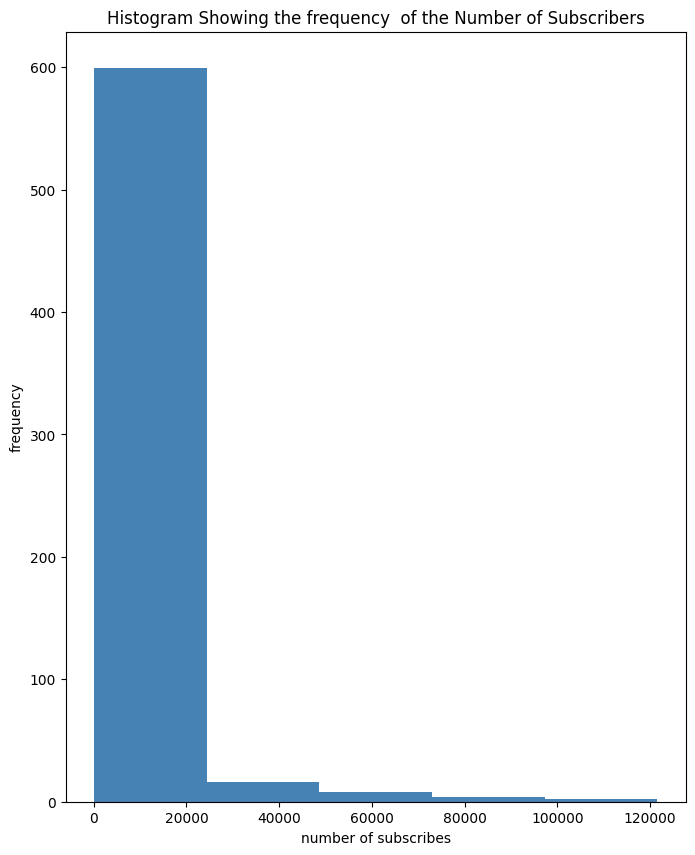

In [ ]:
#A histogram shows the frequency of num subscribes
plt.figure(figsize=(8,10))
plt.hist(df['Num Subscribers'], bins=5, color='steelblue')
plt.xlabel('number of subscribes')
plt.ylabel('frequency')
plt.title('Histogram Showing the frequency  of the Number of Subscribers')
plt.show() #display

# **Bar Chart to show Number of Subscribers each Level:**


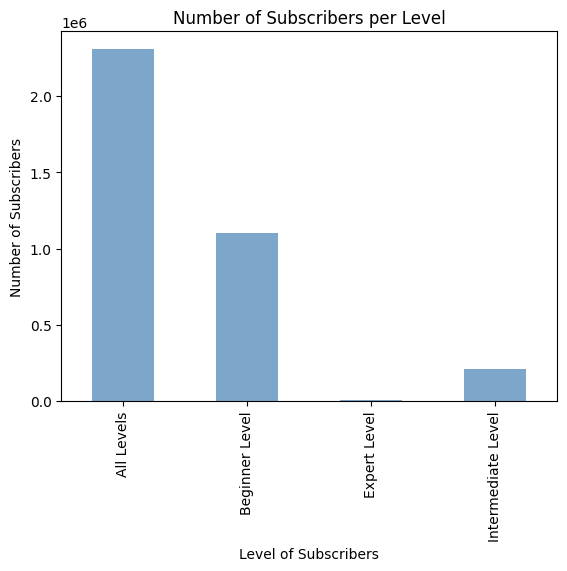

In [ ]:

# Create the bar chart out of the grouped subcribers of each level
groupp.plot(kind='bar',legend=False ,color='steelblue',alpha=0.7)
#put title and labels
plt.xlabel('Level of Subscribers')
plt.ylabel('Number of Subscribers')
plt.title('Number of Subscribers per Level')
plt.show()# display

# **Line Plot to show Content Duration of the courses**



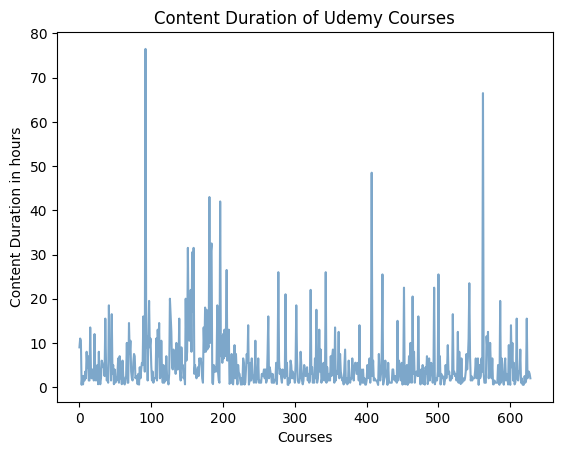

In [ ]:
# create line plot
#speciing the indez as number of courses as the x-axis and content durations in hours as y-axis
plt.plot(df.index, df['Content Duration'], label='Content Duration', color='steelblue' , alpha =0.7)#specifing the
#put title and labels
plt. xlabel( 'Courses')
plt. ylabel('Content Duration in hours')
plt. title('Content Duration of Udemy Courses')
plt. show()#display

# HeatMap to show  correlations

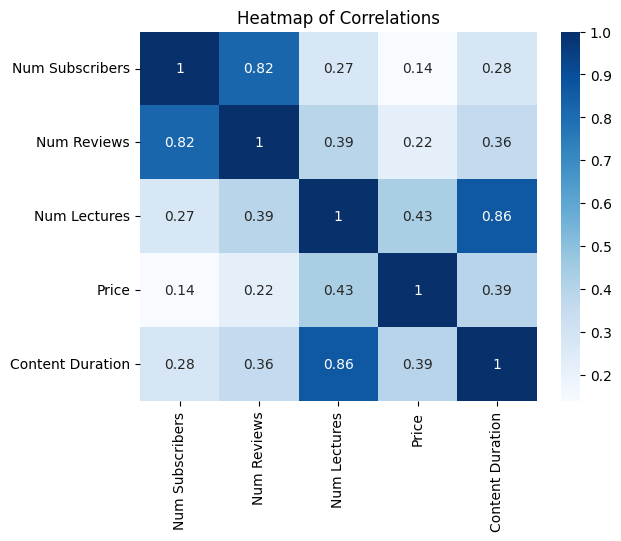

In [ ]:
#create heatmap
sns.heatmap(correlation, cmap='Blues', annot=True)
plt.title('Heatmap of Correlations')
plt.show() #display

# ***Scatter plot***

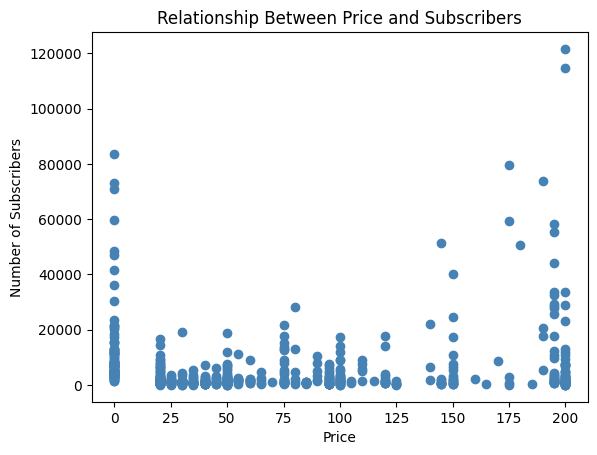

In [ ]:
#creat scatter plot with price and num subscribers as an arguments
plt.scatter(df['Price'],df['Num Subscribers'],color='steelblue')
#adding title and labels
plt.xlabel('Price')
plt.ylabel('Number of Subscribers')
plt.title('Relationship Between Price and Subscribers')
#display the figure
plt.show()

## **word clouds**

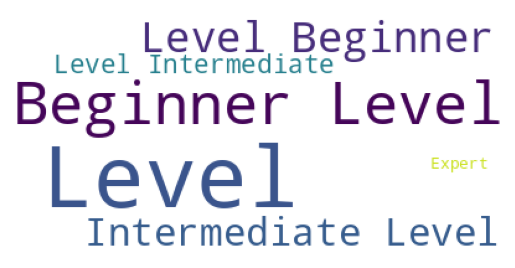

In [ ]:
subject_text = " ".join(df['V']) #combined text data form a columns
wordscloud = WordCloud( background_color='white').generate(subject_text)# creat a word cloud from word cloud library
plt.imshow(wordscloud)
plt.axis('off')
plt.show()



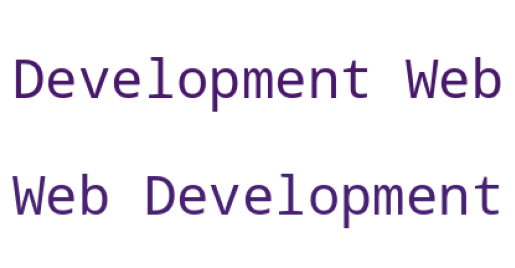

In [ ]:
subject_text = " ".join(df['Subject'])
wordscloud = WordCloud( background_color='white').generate(subject_text)
plt.imshow(wordscloud)
plt.axis('off')
plt.show()
